### STEP 1 — IMPORT LIBRARIES


In [1]:
import pandas as pd
import numpy as np

### STEP 2 — LOAD PREPROCESSED DATASET

In [2]:


file_path = "Tourism_Reviews_Preprocessed.csv"

df = pd.read_csv(
    file_path,
    encoding="utf-8-sig"
)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully.
Rows: 22092
Columns: 21


### STEP 3 — VERIFY REQUIRED COLUMNS


In [3]:

required_columns = [
    "Review_ID",
    "City",
    "Place",
    "Review_Date",
    "Year",
    "Month",
    "Month_Year",
    "Rating",
    "Model_Text"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


### STEP 4 — CHECK MODEL TEXT


In [4]:

print(
    "Missing Model_Text:",
    df["Model_Text"].isna().sum()
)

print(
    "Empty Model_Text:",
    (
        df["Model_Text"]
        .fillna("")
        .str.strip()
        == ""
    ).sum()
)

display(
    df[
        [
            "Review_ID",
            "City",
            "Place",
            "Rating",
            "Model_Text"
        ]
    ].head(10)
)

Missing Model_Text: 7
Empty Model_Text: 7


,Review_ID,City,Place,Rating,Model_Text
0,R000001,Agra,Taj Mahal,5,An amazing experience
1,R000002,Agra,Taj Mahal,5,Awesome place
2,R000003,Agra,Taj Mahal,5,Definitely a wonder of the world
3,R000004,Agra,Taj Mahal,5,Mesmerizing
4,R000005,Agra,Taj Mahal,5,A place really called as wonder
5,R000006,Agra,Taj Mahal,5,It's was a magnificent experience to be seeing...
6,R000007,Agra,Taj Mahal,5,Jaw dropping wonder
7,R000008,Agra,Taj Mahal,4,No wonder it's a wonder!
8,R000009,Agra,Taj Mahal,5,An ambition acheived
9,R000010,Agra,Taj Mahal,5,This is definitely one of the most amazing pla...


## Emotion Classification Model Selection

### Primary Model: 7-Emotion DistilRoBERTa

For the emotion analysis, a **7-emotion DistilRoBERTa model** is selected as the primary emotion classification model. The objective is to transform each tourism review into a structured emotional representation that can subsequently be aggregated over time for emotional drift analysis.

The model classifies text into seven emotion categories:

- **Anger**
- **Disgust**
- **Fear**
- **Joy**
- **Neutral**
- **Sadness**
- **Surprise**

### Rationale for Model Selection

The 7-emotion framework was selected because it provides a useful balance between **emotional detail and interpretability**. A simple sentiment classifier based only on positive, negative, and neutral categories would not capture changes in specific tourist emotions. For example, two periods may both contain predominantly negative reviews while differing substantially in whether tourists express **anger, fear, sadness, or disgust**.

At the same time, using a very large number of fine-grained emotion categories could make monthly aggregation and temporal comparison difficult, particularly for city-months with relatively small numbers of reviews. The seven-emotion representation therefore provides a manageable and interpretable emotional space for the study.

DistilRoBERTa is a transformer-based language model capable of capturing contextual information in review text. This is particularly useful for tourism reviews, where short expressions such as *"Amazing experience"*, *"Too crowded"*, or *"Never again"* may communicate strong emotional information despite containing relatively few words.

### Role in the Analysis Pipeline

The model will be applied to the standardized English `Model_Text` generated during preprocessing. For each review, the analysis will retain the predicted emotion and associated model confidence scores.

These review-level emotion results will subsequently be aggregated by **city, attraction, and time period** to construct temporal emotion profiles.

The resulting emotion distributions will form the basis for:

**Emotion Classification → Monthly Emotion Aggregation → Emotional Drift Measurement → Significant Change Detection → Event Mapping**

This approach allows the study to examine not only whether tourist perceptions became more positive or negative, but also **how the underlying emotional composition of tourism experiences changed over time and whether major changes correspond with identifiable real-world events.**

### STEP 5 — LOAD 7-EMOTION DISTILROBERTA MODEL


In [5]:
from transformers import pipeline

model_name = "j-hartmann/emotion-english-distilroberta-base"

emotion_classifier = pipeline(
    "text-classification",
    model=model_name,
    tokenizer=model_name,
    top_k=None
)

print("Emotion model loaded successfully.")
print("Model:", model_name)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Emotion model loaded successfully.
Model: j-hartmann/emotion-english-distilroberta-base


### STEP 6 — TEST EMOTION MODEL ON SAMPLE


In [6]:
sample_df = df[
    [
        "Review_ID",
        "Rating",
        "Model_Text"
    ]
].head(10).copy()


In [7]:

def classify_emotions(text):

    results = emotion_classifier(
        str(text),
        truncation=True,
        max_length=512
    )

    # Some transformers versions return:
    # [[{label, score}, ...]]
    # instead of:
    # [{label, score}, ...]
    if (
        isinstance(results, list)
        and len(results) > 0
        and isinstance(results[0], list)
    ):
        results = results[0]

    # Sort highest probability first
    results = sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

    dominant_emotion = results[0]["label"]
    dominant_score = results[0]["score"]

    return (
        dominant_emotion,
        dominant_score,
        results
    )


sample_df[
    [
        "Dominant_Emotion",
        "Emotion_Score",
        "All_Emotion_Scores"
    ]
] = sample_df["Model_Text"].apply(
    lambda text: pd.Series(
        classify_emotions(text)
    )
)


display(
    sample_df[
        [
            "Review_ID",
            "Rating",
            "Model_Text",
            "Dominant_Emotion",
            "Emotion_Score",
            "All_Emotion_Scores"
        ]
    ]
)

,Review_ID,Rating,Model_Text,Dominant_Emotion,Emotion_Score,All_Emotion_Scores
0,R000001,5,An amazing experience,joy,0.485461,"[{'label': 'joy', 'score': 0.4854612946510315}..."
1,R000002,5,Awesome place,joy,0.797196,"[{'label': 'joy', 'score': 0.7971959710121155}..."
2,R000003,5,Definitely a wonder of the world,surprise,0.915380,"[{'label': 'surprise', 'score': 0.915380001068..."
3,R000004,5,Mesmerizing,neutral,0.864298,"[{'label': 'neutral', 'score': 0.8642978668212..."
4,R000005,5,A place really called as wonder,surprise,0.978191,"[{'label': 'surprise', 'score': 0.978191018104..."
5,R000006,5,It's was a magnificent experience to be seeing...,joy,0.882879,"[{'label': 'joy', 'score': 0.8828786611557007}..."
6,R000007,5,Jaw dropping wonder,neutral,0.438689,"[{'label': 'neutral', 'score': 0.4386890828609..."
7,R000008,4,No wonder it's a wonder!,surprise,0.926868,"[{'label': 'surprise', 'score': 0.926868319511..."
8,R000009,5,An ambition acheived,anger,0.220565,"[{'label': 'anger', 'score': 0.220565289258956..."
9,R000010,5,This is definitely one of the most amazing pla...,joy,0.646265,"[{'label': 'joy', 'score': 0.6462646722793579}..."


### STEP 7 — EXPAND ALL 7 EMOTION SCORES


In [8]:

emotion_labels = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
]


def extract_emotion_scores(text):

    results = emotion_classifier(
        str(text),
        truncation=True,
        max_length=512
    )

    # Handle nested output format
    if (
        isinstance(results, list)
        and len(results) > 0
        and isinstance(results[0], list)
    ):
        results = results[0]

    scores = {
        item["label"].lower(): item["score"]
        for item in results
    }

    # Dominant emotion
    dominant_emotion = max(
        scores,
        key=scores.get
    )

    dominant_score = scores[
        dominant_emotion
    ]

    return pd.Series({
        "Anger": scores.get("anger", 0),
        "Disgust": scores.get("disgust", 0),
        "Fear": scores.get("fear", 0),
        "Joy": scores.get("joy", 0),
        "Neutral": scores.get("neutral", 0),
        "Sadness": scores.get("sadness", 0),
        "Surprise": scores.get("surprise", 0),
        "Dominant_Emotion": dominant_emotion,
        "Dominant_Emotion_Score": dominant_score
    })

### STEP 8 — TEST 7-SCORE OUTPUT


In [9]:

test_emotions = (
    df["Model_Text"]
    .head(10)
    .apply(extract_emotion_scores)
)

test_output = pd.concat(
    [
        df[
            [
                "Review_ID",
                "Rating",
                "Model_Text"
            ]
        ].head(10).reset_index(drop=True),

        test_emotions.reset_index(drop=True)
    ],
    axis=1
)

display(test_output)

,Review_ID,Rating,Model_Text,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise,Dominant_Emotion,Dominant_Emotion_Score
0,R000001,5,An amazing experience,0.005210,0.003741,0.030083,0.485461,0.052319,0.008267,0.414919,joy,0.485461
1,R000002,5,Awesome place,0.003087,0.002857,0.003248,0.797196,0.060793,0.003041,0.129778,joy,0.797196
2,R000003,5,Definitely a wonder of the world,0.004154,0.002859,0.006706,0.015444,0.052878,0.002578,0.915380,surprise,0.915380
3,R000004,5,Mesmerizing,0.015222,0.049447,0.011290,0.022652,0.864298,0.023749,0.013341,neutral,0.864298
4,R000005,5,A place really called as wonder,0.001923,0.000642,0.003407,0.008736,0.005524,0.001576,0.978191,surprise,0.978191
5,R000006,5,It's was a magnificent experience to be seeing...,0.002966,0.002859,0.025148,0.882879,0.033369,0.002797,0.049982,joy,0.882879
6,R000007,5,Jaw dropping wonder,0.015360,0.027183,0.025623,0.018045,0.438689,0.087054,0.388046,neutral,0.438689
7,R000008,4,No wonder it's a wonder!,0.010503,0.002241,0.002385,0.022191,0.030920,0.004891,0.926868,surprise,0.926868
8,R000009,5,An ambition acheived,0.220565,0.193781,0.145935,0.046004,0.173696,0.188921,0.031098,anger,0.220565
9,R000010,5,This is definitely one of the most amazing pla...,0.006585,0.002815,0.004888,0.646265,0.217964,0.005105,0.116378,joy,0.646265


### STEP 9 — VALIDATE EMOTION OUTPUT

In [10]:
emotion_columns = [
    "Anger",
    "Disgust",
    "Fear",
    "Joy",
    "Neutral",
    "Sadness",
    "Surprise"
]

# Check probability sum
test_output["Emotion_Sum"] = (
    test_output[emotion_columns].sum(axis=1)
)

print("Emotion probability sums:")

display(
    test_output[
        [
            "Review_ID",
            "Model_Text",
            "Dominant_Emotion",
            "Dominant_Emotion_Score",
            "Emotion_Sum"
        ]
    ]
)

print(
    "\nMinimum probability sum:",
    test_output["Emotion_Sum"].min()
)

print(
    "Maximum probability sum:",
    test_output["Emotion_Sum"].max()
)

Emotion probability sums:


,Review_ID,Model_Text,Dominant_Emotion,Dominant_Emotion_Score,Emotion_Sum
0,R000001,An amazing experience,joy,0.485461,1.0
1,R000002,Awesome place,joy,0.797196,1.0
2,R000003,Definitely a wonder of the world,surprise,0.915380,1.0
3,R000004,Mesmerizing,neutral,0.864298,1.0
4,R000005,A place really called as wonder,surprise,0.978191,1.0
5,R000006,It's was a magnificent experience to be seeing...,joy,0.882879,1.0
6,R000007,Jaw dropping wonder,neutral,0.438689,1.0
7,R000008,No wonder it's a wonder!,surprise,0.926868,1.0
8,R000009,An ambition acheived,anger,0.220565,1.0
9,R000010,This is definitely one of the most amazing pla...,joy,0.646265,1.0



Minimum probability sum: 0.9999998910352588
Maximum probability sum: 1.000000049592927


### STEP 10 — CHECK LOW-CONFIDENCE PREDICTIONS


In [11]:

low_confidence = test_output[
    test_output["Dominant_Emotion_Score"] < 0.50
]

print(
    "Predictions with confidence below 0.50:",
    len(low_confidence)
)

display(
    low_confidence[
        [
            "Review_ID",
            "Rating",
            "Model_Text",
            "Dominant_Emotion",
            "Dominant_Emotion_Score",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ]
)

Predictions with confidence below 0.50: 3


,Review_ID,Rating,Model_Text,Dominant_Emotion,Dominant_Emotion_Score,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
0,R000001,5,An amazing experience,joy,0.485461,0.005210,0.003741,0.030083,0.485461,0.052319,0.008267,0.414919
6,R000007,5,Jaw dropping wonder,neutral,0.438689,0.015360,0.027183,0.025623,0.018045,0.438689,0.087054,0.388046
8,R000009,5,An ambition acheived,anger,0.220565,0.220565,0.193781,0.145935,0.046004,0.173696,0.188921,0.031098


### STEP 11 — RUN EMOTION MODEL ON FULL DATASET


In [12]:

from tqdm.auto import tqdm
import pandas as pd
import os

emotion_columns = [
    "Anger",
    "Disgust",
    "Fear",
    "Joy",
    "Neutral",
    "Sadness",
    "Surprise"
]

texts = (
    df["Model_Text"]
    .fillna("")
    .astype(str)
    .tolist()
)

batch_size = 32

all_results = []

print("Total reviews:", len(texts))
print("Starting emotion classification...")

for start in tqdm(
    range(0, len(texts), batch_size),
    desc="Emotion Classification"
):

    batch_texts = texts[
        start:start + batch_size
    ]

    batch_results = emotion_classifier(
        batch_texts,
        truncation=True,
        max_length=512,
        batch_size=batch_size
    )

    # Process every review in the batch
    for result in batch_results:

        # Handle nested output if necessary
        if (
            isinstance(result, list)
            and len(result) == 1
            and isinstance(result[0], list)
        ):
            result = result[0]

        scores = {
            item["label"].lower(): item["score"]
            for item in result
        }

        dominant_emotion = max(
            scores,
            key=scores.get
        )

        all_results.append({
            "Anger": scores.get("anger", 0),
            "Disgust": scores.get("disgust", 0),
            "Fear": scores.get("fear", 0),
            "Joy": scores.get("joy", 0),
            "Neutral": scores.get("neutral", 0),
            "Sadness": scores.get("sadness", 0),
            "Surprise": scores.get("surprise", 0),

            "Dominant_Emotion":
                dominant_emotion,

            "Dominant_Emotion_Score":
                scores[dominant_emotion]
        })


print("\nEmotion classification completed.")
print("Results:", len(all_results))

Total reviews: 22092
Starting emotion classification...


Emotion Classification:   0%|          | 0/691 [00:00<?, ?it/s]


Emotion classification completed.
Results: 22092


### STEP 12 — ADD EMOTION RESULTS TO DATASET


In [13]:

emotion_df = pd.DataFrame(all_results)

print("Dataset rows:", len(df))
print("Emotion results:", len(emotion_df))

if len(df) == len(emotion_df):

    for column in emotion_df.columns:
        df[column] = emotion_df[column].values

    print("Emotion results added successfully.")

else:
    print("ERROR: Row counts do not match.")

Dataset rows: 22092
Emotion results: 22092
Emotion results added successfully.


In [14]:
display(
    df[
        [
            "Review_ID",
            "Rating",
            "Model_Text",
            "Dominant_Emotion",
            "Dominant_Emotion_Score",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ].head(20)
)

,Review_ID,Rating,Model_Text,Dominant_Emotion,Dominant_Emotion_Score,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
0,R000001,5,An amazing experience,joy,0.485461,0.005210,0.003741,0.030083,0.485461,0.052319,0.008267,0.414919
1,R000002,5,Awesome place,joy,0.797196,0.003087,0.002857,0.003248,0.797196,0.060793,0.003041,0.129778
2,R000003,5,Definitely a wonder of the world,surprise,0.915380,0.004154,0.002859,0.006706,0.015445,0.052878,0.002578,0.915380
3,R000004,5,Mesmerizing,neutral,0.864298,0.015222,0.049447,0.011290,0.022652,0.864298,0.023749,0.013341
4,R000005,5,A place really called as wonder,surprise,0.978191,0.001923,0.000642,0.003407,0.008736,0.005524,0.001576,0.978191
5,R000006,5,It's was a magnificent experience to be seeing...,joy,0.882879,0.002966,0.002859,0.025148,0.882879,0.033369,0.002797,0.049982
6,R000007,5,Jaw dropping wonder,neutral,0.438689,0.015360,0.027183,0.025623,0.018045,0.438689,0.087054,0.388046
7,R000008,4,No wonder it's a wonder!,surprise,0.926868,0.010503,0.002241,0.002385,0.022191,0.030920,0.004891,0.926868
8,R000009,5,An ambition acheived,anger,0.220565,0.220565,0.193781,0.145935,0.046003,0.173696,0.188921,0.031098
9,R000010,5,This is definitely one of the most amazing pla...,joy,0.646265,0.006585,0.002815,0.004888,0.646265,0.217964,0.005105,0.116378


### STEP 13 — VALIDATE FULL EMOTION RESULTS


In [15]:

emotion_columns = [
    "Anger",
    "Disgust",
    "Fear",
    "Joy",
    "Neutral",
    "Sadness",
    "Surprise"
]

print("Total reviews:", len(df))

print(
    "Missing dominant emotions:",
    df["Dominant_Emotion"].isna().sum()
)

print(
    "Missing emotion scores:",
    df[emotion_columns].isna().sum().sum()
)

# Check probability sums
emotion_sum = df[emotion_columns].sum(axis=1)

print(
    "Minimum probability sum:",
    emotion_sum.min()
)

print(
    "Maximum probability sum:",
    emotion_sum.max()
)

print(
    "Mean probability sum:",
    emotion_sum.mean()
)

Total reviews: 22092
Missing dominant emotions: 0
Missing emotion scores: 0
Minimum probability sum: 0.9999997743871063
Maximum probability sum: 1.0000002314336598
Mean probability sum: 0.9999999998325081


In [16]:
print("\nDOMINANT EMOTION DISTRIBUTION")

emotion_distribution = (
    df["Dominant_Emotion"]
    .value_counts()
    .rename_axis("Emotion")
    .reset_index(name="Count")
)

emotion_distribution["Percentage"] = (
    emotion_distribution["Count"]
    / len(df) * 100
).round(2)

display(emotion_distribution)


DOMINANT EMOTION DISTRIBUTION


,Emotion,Count,Percentage
0,neutral,8278,37.47
1,joy,7612,34.46
2,surprise,2835,12.83
3,sadness,1331,6.02
4,fear,845,3.82
5,disgust,810,3.67
6,anger,381,1.72


### STEP 14A — DOMINANT EMOTION DISTRIBUTION


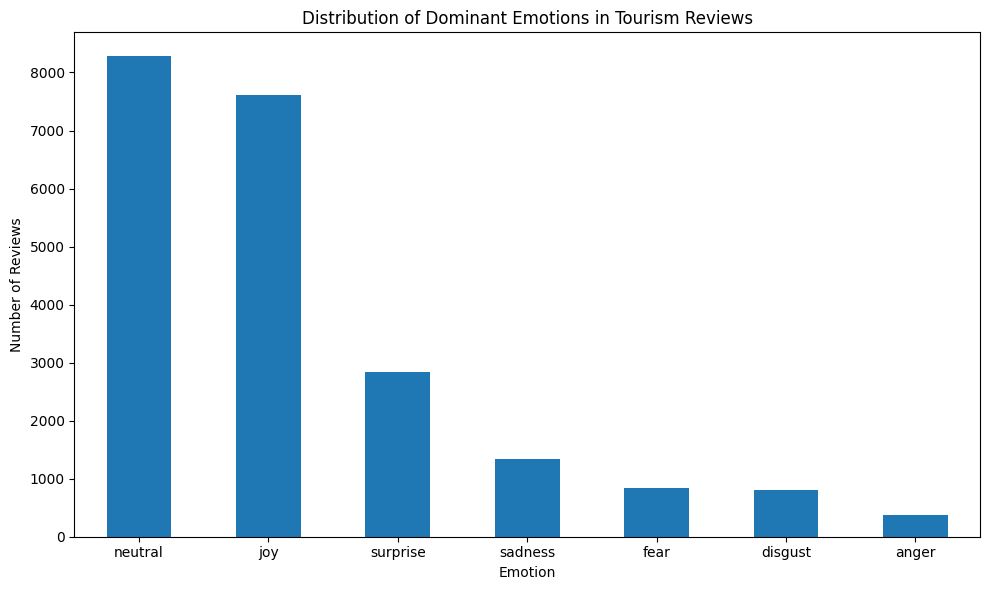

In [17]:

import matplotlib.pyplot as plt

emotion_counts = (
    df["Dominant_Emotion"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

emotion_counts.plot(
    kind="bar"
)

plt.title("Distribution of Dominant Emotions in Tourism Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### STEP 14B — DOMINANT EMOTION PERCENTAGE


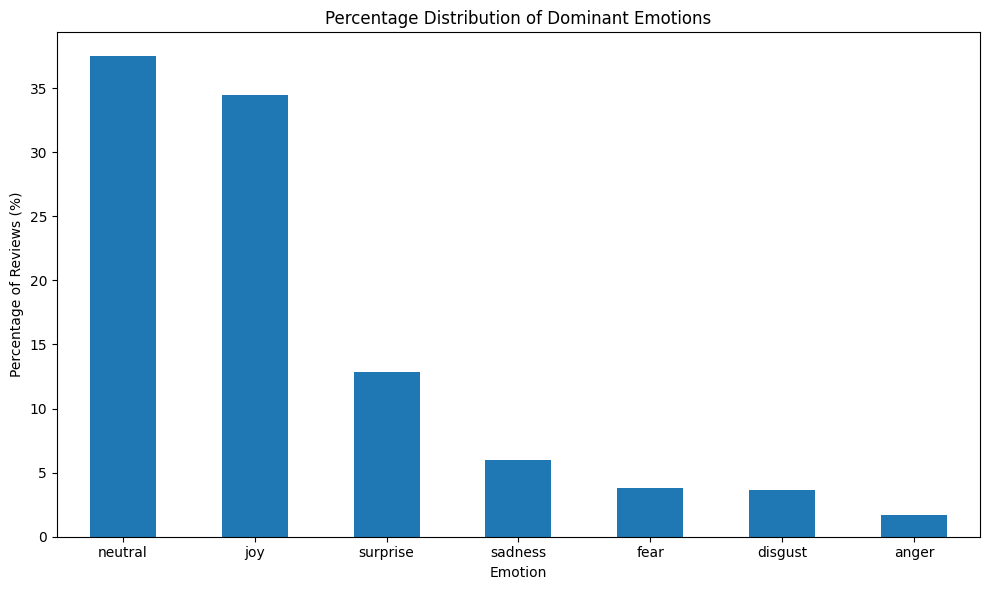

,Emotion,Percentage
0,neutral,37.47
1,joy,34.46
2,surprise,12.83
3,sadness,6.02
4,fear,3.82
5,disgust,3.67
6,anger,1.72


In [18]:

emotion_percentage = (
    df["Dominant_Emotion"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

emotion_percentage.plot(
    kind="bar"
)

plt.title("Percentage Distribution of Dominant Emotions")
plt.xlabel("Emotion")
plt.ylabel("Percentage of Reviews (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

display(
    emotion_percentage
    .rename("Percentage")
    .reset_index()
    .rename(columns={"Dominant_Emotion": "Emotion"})
)

### STEP 14C — AVERAGE EMOTION PROBABILITY


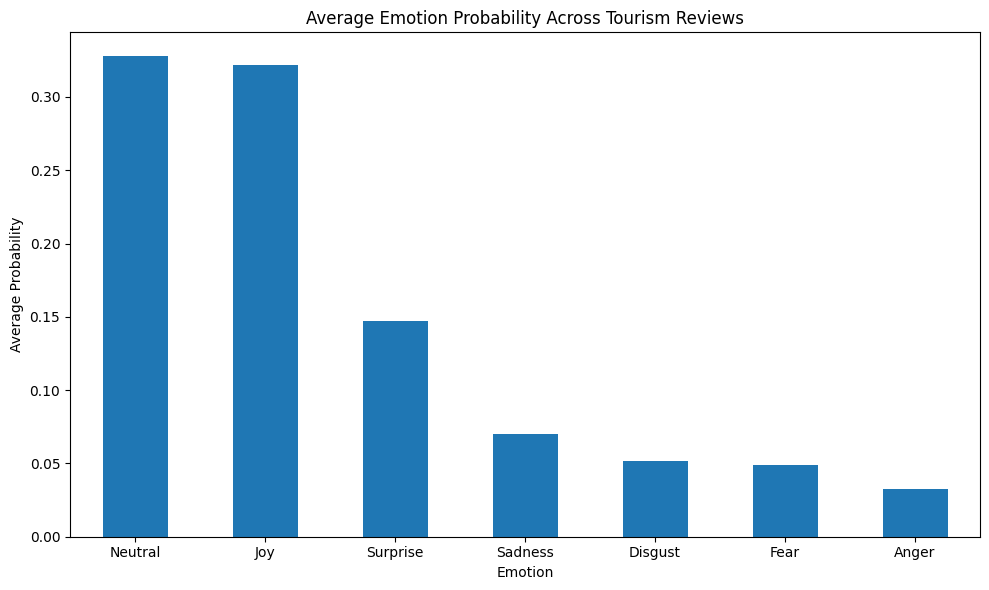

In [19]:

emotion_columns = [
    "Anger",
    "Disgust",
    "Fear",
    "Joy",
    "Neutral",
    "Sadness",
    "Surprise"
]

average_emotions = (
    df[emotion_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

average_emotions.plot(
    kind="bar"
)

plt.title("Average Emotion Probability Across Tourism Reviews")
plt.xlabel("Emotion")
plt.ylabel("Average Probability")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### STEP 15 — SAVE EMOTION-CLASSIFIED DATASET


In [20]:

output_file = "Tourism_Reviews_Emotion.csv"

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Emotion dataset saved successfully.")
print("File:", output_file)
print("Total reviews:", len(df))

Emotion dataset saved successfully.
File: Tourism_Reviews_Emotion.csv
Total reviews: 22092


## Emotion Analysis Summary

The emotion analysis stage applied the **7-emotion DistilRoBERTa model** to the standardized tourism review text produced during preprocessing. The objective was to convert each review into a structured emotional representation that can be used for subsequent temporal emotional-drift analysis.

### Dataset and Model

- **Total reviews analyzed:** 22,092
- **Cities:** 10
- **Tourist attractions:** 48
- **Study period:** 2019–2024
- **Primary model:** 7-Emotion DistilRoBERTa
- **Input:** `Model_Text`
- **Output dataset:** `Tourism_Reviews_Emotion.csv`

The model generated probability scores for seven emotion categories:

**Anger, Disgust, Fear, Joy, Neutral, Sadness, and Surprise**

For each review, both the **dominant emotion** and the complete seven-emotion probability distribution were retained. Keeping the full probability distribution is important because some reviews contain mixed or uncertain emotional signals that cannot be adequately represented by a single label.

### Overall Emotion Distribution

The dominant emotion distribution across the complete dataset was:

| Emotion | Percentage |
|---|---:|
| Neutral | 37.47% |
| Joy | 34.46% |
| Surprise | 12.83% |
| Sadness | 6.02% |
| Fear | 3.82% |
| Disgust | 3.67% |
| Anger | 1.72% |

### Initial Findings

**Neutral (37.47%)** was the most frequently predicted dominant emotion, closely followed by **Joy (34.46%)**. Together, these two categories represent the majority of the reviews.

**Surprise (12.83%)** was the third most frequent emotion, indicating that reactions involving amazement, wonder, or unexpected experiences also form a notable component of tourist reviews.

Negative emotions occurred less frequently, with **Sadness (6.02%)**, **Fear (3.82%)**, **Disgust (3.67%)**, and **Anger (1.72%)** accounting for smaller proportions of the dataset.

These results provide an overall description of the emotional composition of the dataset. However, the global distribution alone does not reveal how tourist emotions changed over time or across destinations.

### Final Outcome

The emotion-classified dataset retains both review-level dominant emotion labels and the seven continuous emotion probability scores. These probability scores provide the emotional vectors required for the next stage of the research.

The next stage will move from **static emotion classification to temporal analysis** by aggregating emotion probabilities by time period and destination.

**Next analysis pipeline:**

Emotion Classification  
→ Monthly Emotion Aggregation  
→ Emotional Profile Construction  
→ Emotional Drift Measurement  
→ Significant Drift / Spike Detection  
→ Review-Level Investigation  
→ Real-World Event Mapping  
→ Cross-Destination Comparison

This enables the study to investigate not only the emotions expressed in tourism reviews, but also **when, where, and how tourist emotions changed over time and whether significant emotional shifts correspond with identifiable real-world events.**